In [5]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
import cc3d

Noter:
- Varie n_max med temperatur.
- Beregn std på mean

In [6]:
def delta_E_total(array,nnn_array,i,J=1,h=0,nnn=False):
    N=len(array)
    delta_E = -2*array[i]*(array[(i+1)%N]+array[i-1])
    
    if nnn==True:
        shuffle_index = np.argwhere(nnn_array==i)[0]
        up_index = nnn_array[(shuffle_index+1)%N][0]
        down_index = nnn_array[(shuffle_index-1)][0]
        delta_E += -2*array[i]*(array[(up_index)%N]+array[down_index])

    delta_E *= -J
    delta_E += 2*h*array[i]
    return delta_E


def count_domain_size(array):
    labels = cc3d.connected_components(array,connectivity=6)
    if array[0]==array[-1]:
        labels[labels == max(labels)] = 1
    sizes = np.bincount(labels)[1:]
    return sizes

def nn_sim(N_site,T,n_max=10**3,skip=10,J=1,h=0):
    array = 2*random.randint(2,size=N_site)-1

    E = [0]
    m = [np.sum(array)]
    current_energy=0

    # prepare random numbers
    index = random.randint(N_site,size=n_max)
    select = random.rand(n_max)

    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array,[],i,h=h)
        prev_energy = current_energy
        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
            current_energy = prev_energy+delta_E
        else:
            current_energy = prev_energy
        
        if l%skip==0:
            #print(delta_E,selection)
            E.append(current_energy)
            m.append(np.sum(array))
            #print(delta_E,selection)

    E = np.array(E)/N_site
    m = np.array(m)/N_site

    return E,m,array

def nnn_sim(N_site,T,n_max=10**3,skip=10,J=1,h=0):
    
    shuffle_array = np.loadtxt("nnn_array//shuffle_"+str(N_site)+".txt").astype(int)

    array = 2*random.randint(2,size=N_site)-1

    E = [0]
    m = [np.sum(array)]
    current_energy=0

    # prepare random numbers
    index = random.randint(N_site,size=n_max)
    select = random.rand(n_max)

    for l in range(n_max):
        i = index[l]
        delta_E=delta_E_total(array,shuffle_array,i,h=h,nnn=True)
        prev_energy = current_energy
        if delta_E <= 0 or select[l] < np.exp(-delta_E/T):
            array[i]*=-1
            current_energy = prev_energy+delta_E
        else:
            current_energy = prev_energy
        
        if l%skip==0:
            #print(delta_E,selection)
            E.append(current_energy)
            m.append(np.sum(array))
            #print(delta_E,selection)

    E = np.array(E)/N_site
    m = np.array(m)/N_site

    return E,m,array

In [7]:
array = np.array([1,1,1,1,1,-1,-1,-1,-1,1,1,1,1])
print(cc3d.connected_components(array,connectivity=6,periodic_boundary=True))

[1 1 1 1 1 2 2 2 2 3 3 3 3]


0


KeyboardInterrupt: 

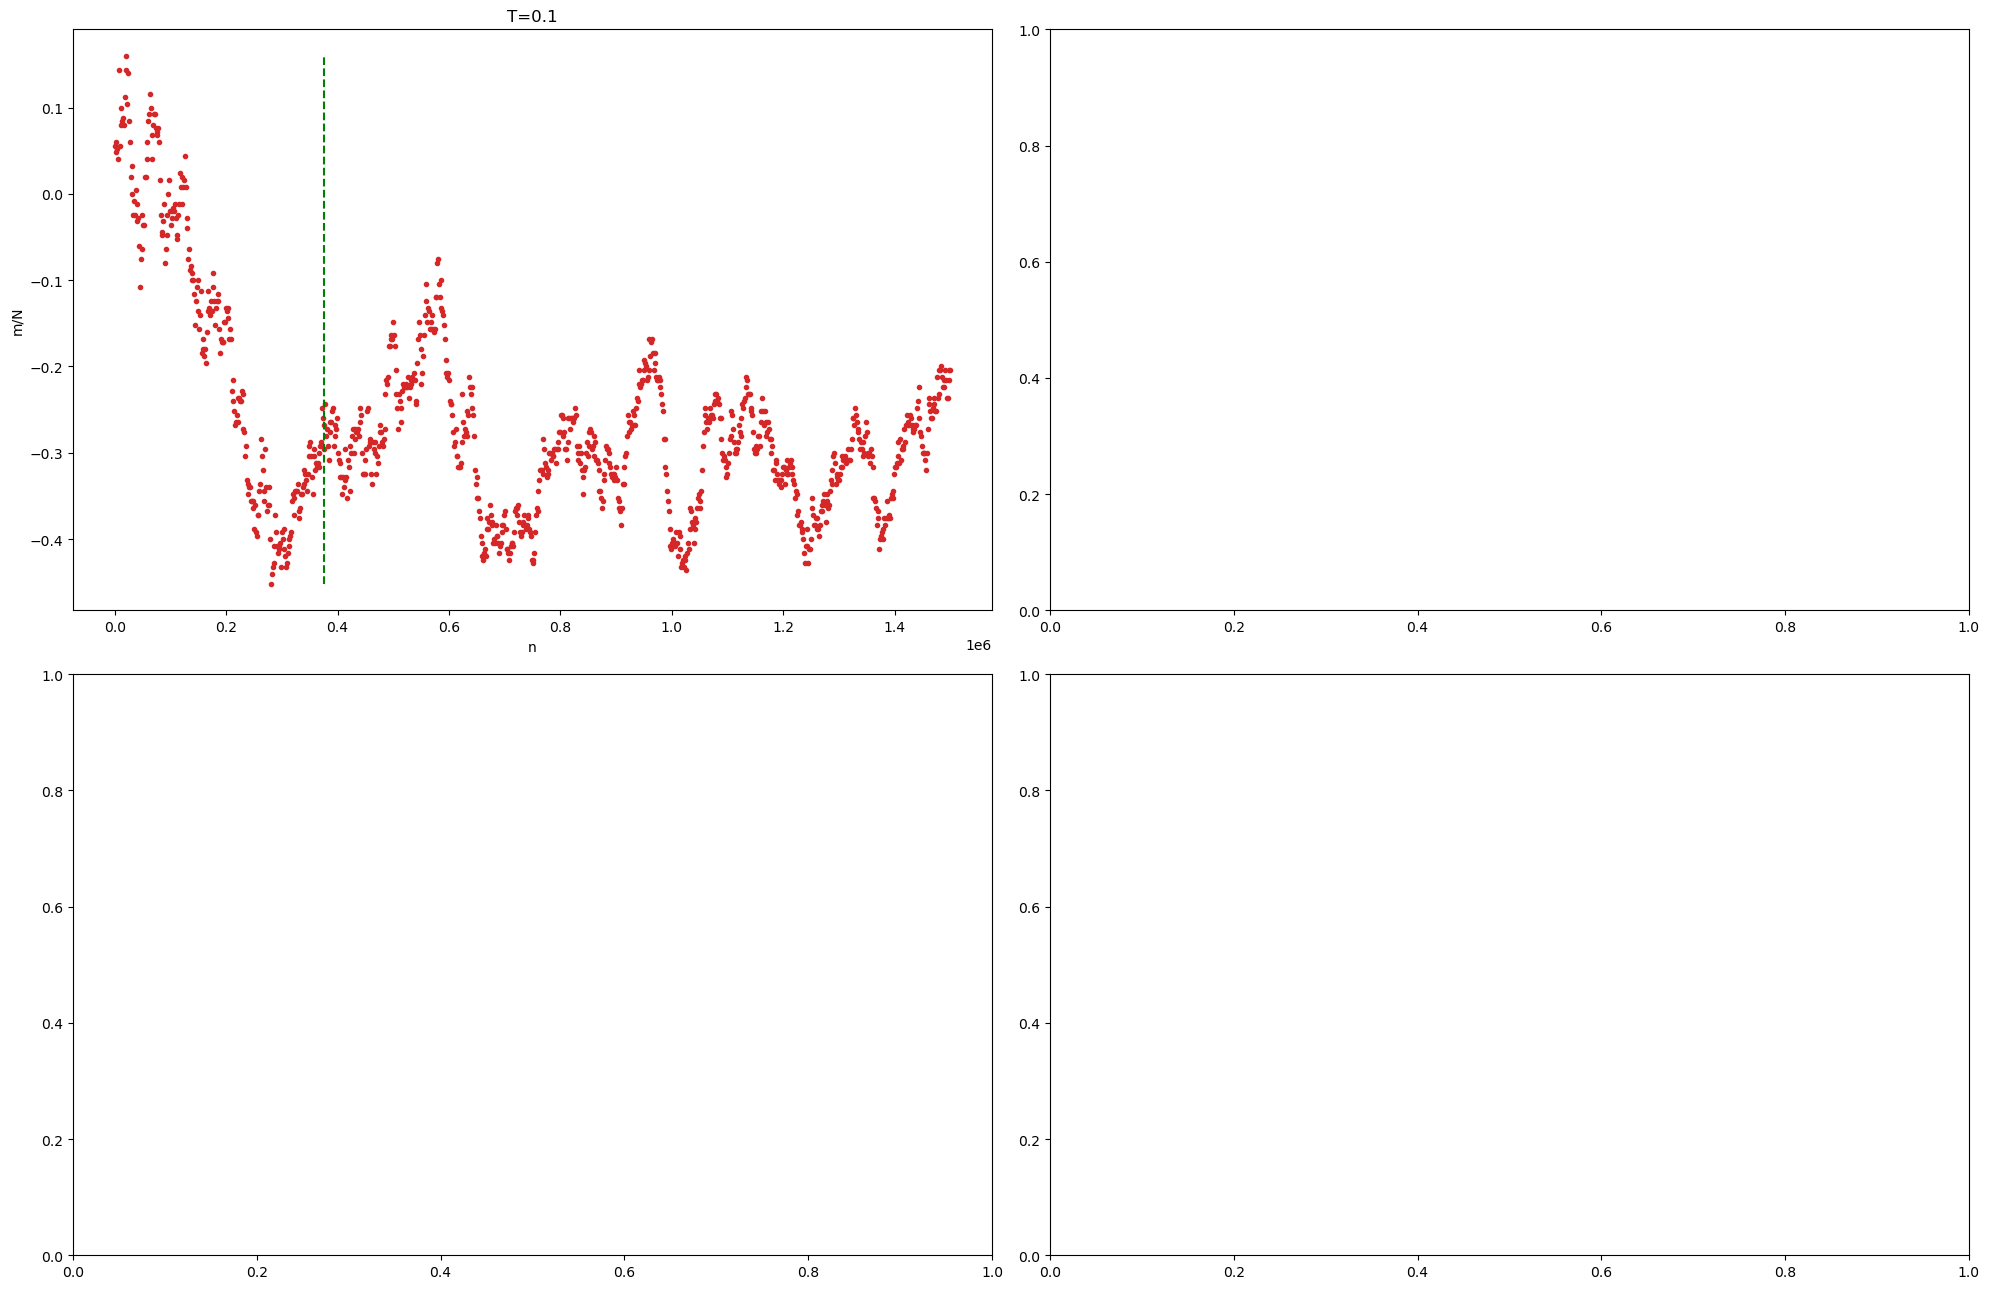

In [8]:
# run nn simulation

T_list = np.linspace(0.1,4,100)

E_mean_list = []
m_mean_list = []
domain_mean_list = []
E_err_list = []
m_err_list = []

index_for_plot = [0,int(len(T_list)/3),int(2*len(T_list)/3),len(T_list)-1]
if index_for_plot:
        fig,ax = plt.subplots(int(len(index_for_plot)/2),2,figsize = (20,13))
count = 0

N_site=500
n_max = 10**3*N_site
h=0

for index, T in enumerate(T_list):
    if index%10==0:
         print(index)
    if T<0.5:
        n_max*=3

    skip=int(n_max/1000)
    n_0=int(n_max/4)

    E,m,final_array=nn_sim(N_site,T,n_max=n_max,skip=skip,h=h)

    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
        axis.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1
    
    E_mean = np.mean(E[int(n_0/skip):])
    E_mean_std = np.std(E[int(n_0/skip)])
    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip)])
    domain_mean_list.append(np.mean(count_domain_size(final_array)))
    E_mean_list.append(E_mean)
    m_mean_list.append(m_mean)
    E_err_list.append(E_mean)
    m_err_list.append(m_mean)

fig.savefig(".//data//nn_m_plots.png")
plt.show()

In [ ]:
save_array = np.vstack((T_list,E_mean_list,E_err_list,m_mean_list,m_err_list,domain_mean_list)).T
print(np.shape(save_array))
np.savetxt(".//Data//nnn.txt",save_array,header="T,E,E_err,m,m_err,size")

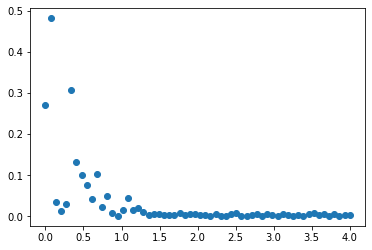

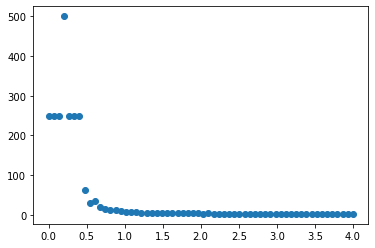

In [ ]:
plt.scatter(T_list,abs(np.array(m_mean_list)))
plt.show()
plt.scatter(T_list,domain_mean_list)

In [9]:
n_max =3*10**6
T=0.15
N_site=400
h=0
skip=int(n_max/300)
n_0 = n_max/4

E,m,final_array=nn_sim(N_site,T,n_max=n_max,skip=skip,h=h)

301


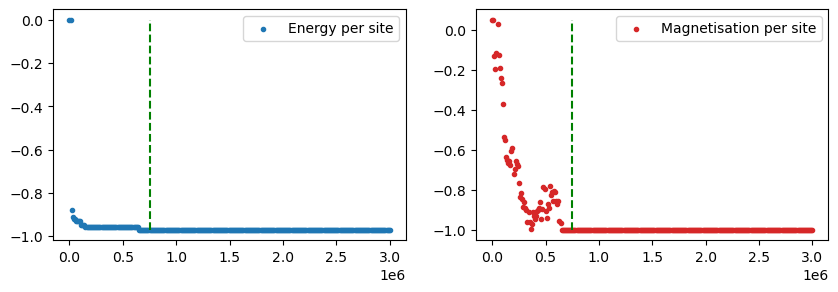

In [20]:
n_0 = n_max/4
print(len(E))
fig,(ax0,ax1) = plt.subplots(1,2,figsize=(10,3))
ax0.scatter(np.arange(len(m))*skip,E,marker='.',label="Energy per site")
ax1.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
ax0.plot([n_0,n_0],[min(E),max(E)],linestyle="dashed",color="green")
ax1.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
#ax2.imshow(final_array)
ax0.legend()
ax1.legend()
#fig.tight_layout()
plt.show()


As cab be seen above, the system orderm but it is slow and VERY unstable

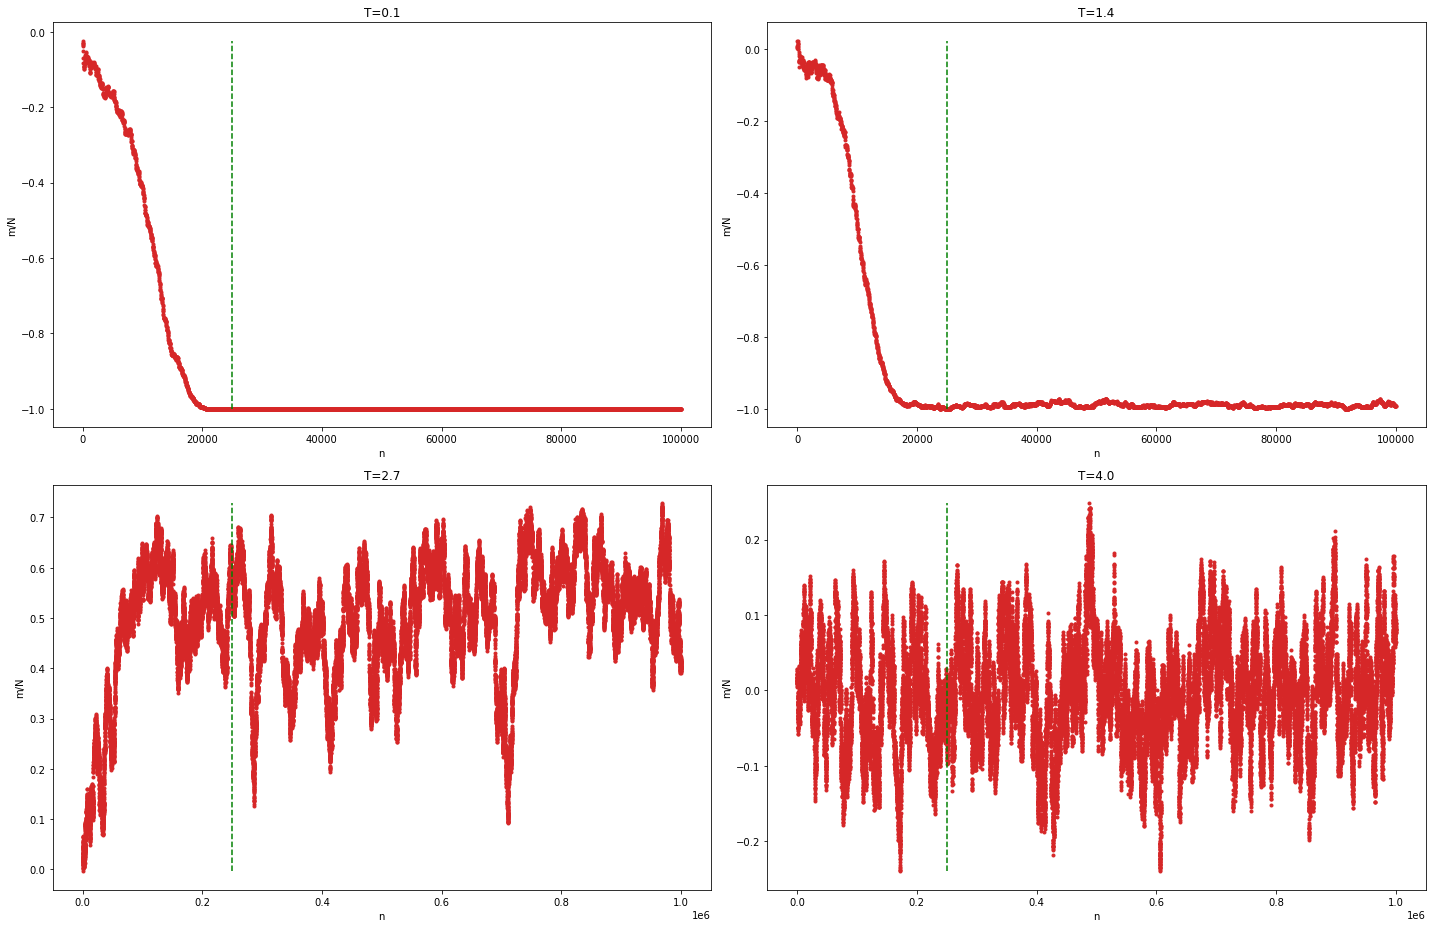

In [ ]:
# run nnn simulation
T_list = np.linspace(0.1,4,100)

E_mean_list = []
m_mean_list = []
domain_mean_list = []
E_err_list = []
m_err_list = []

index_for_plot = [0,int(len(T_list)/3),int(2*len(T_list)/3),len(T_list)-1]
if index_for_plot:
        fig,ax = plt.subplots(int(len(index_for_plot)/2),2,figsize = (20,13))
count = 0

N_site=1000
n_max = 10**3*N_site
h=0

for index, T in enumerate(T_list):
    if T< 2:
        n_max*=1/10

    skip=int(n_max/1000)
    n_0=int(n_max/4)

    if index%10==0:
         print(index)

    E,m,final_array=nnn_sim(N_site,T,n_max=int(n_max),skip=20,h=h)
    
    if index in index_for_plot:
        axis = ax.flatten()[count]
        axis.scatter(np.arange(len(m))*skip,m,marker='.',label="Magnetisation per site",color="tab:red")
        axis.plot([n_0,n_0],[min(m),max(m)],linestyle="dashed",color="green")
        axis.set_title("T="+str(np.round(T,2)))
        axis.set_xlabel("n")
        axis.set_ylabel("m/N")
        fig.tight_layout()
        count+=1


    E_mean = np.mean(E[int(n_0/skip):])
    E_mean_std = np.std(E[int(n_0/skip)])
    m_mean = np.mean(m[int(n_0/skip):])
    m_mean_std = np.std(m[int(n_0/skip)])
    domain_mean_list.append(np.mean(count_domain_size(final_array)))
    E_mean_list.append(E_mean)
    m_mean_list.append(m_mean)
    E_err_list.append(E_mean)
    m_err_list.append(m_mean)

fig.savefig(".//data//nnn_m_plots.png")
plt.show()

In [ ]:
save_array = np.vstack((T_list,E_mean_list,E_err_list,m_mean_list,m_err_list,domain_mean_list)).T
print(np.shape(save_array))
np.savetxt(".//Data//nnn.txt",save_array,header="T,E,E_err,m,m_err,size")

(100, 4)


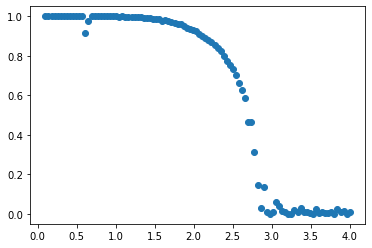

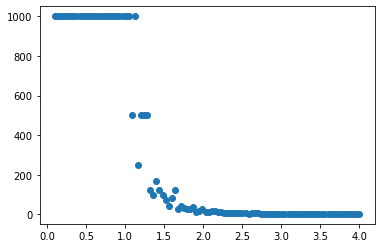

In [ ]:
plt.scatter(T_list,abs(np.array(m_mean_list)))
plt.show()
plt.scatter(T_list,domain_mean_list)

In [81]:
def create_nnn_shuffle(N_site):
    index = np.arange(N_site)
    shuffle = [0]
    for i in range(1,N_site):
        choices = [x for x in index if (x not in shuffle) and (((x-1)%N_site-shuffle[-1]!=0)) and (((x+1)%N_site-shuffle[-1]!=0))]
        choice = random.choice(choices)
        shuffle.append(choice)

    shuffle = np.array(shuffle)
    np.savetxt("nnn_array//shuffle_"+str(N_site)+".txt",shuffle.astype(int))

create_nnn_shuffle(1000)